Using device: cuda
Total samples: 894
Columns: ['child_id', 'label']

Label distribution:
label
1     79
2    156
3    195
4    215
5    138
6     89
7     22
Name: count, dtype: int64


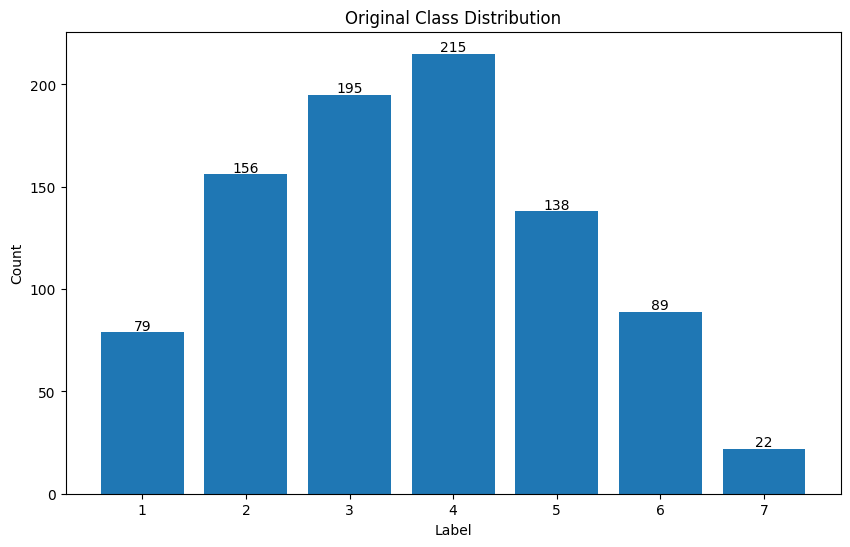

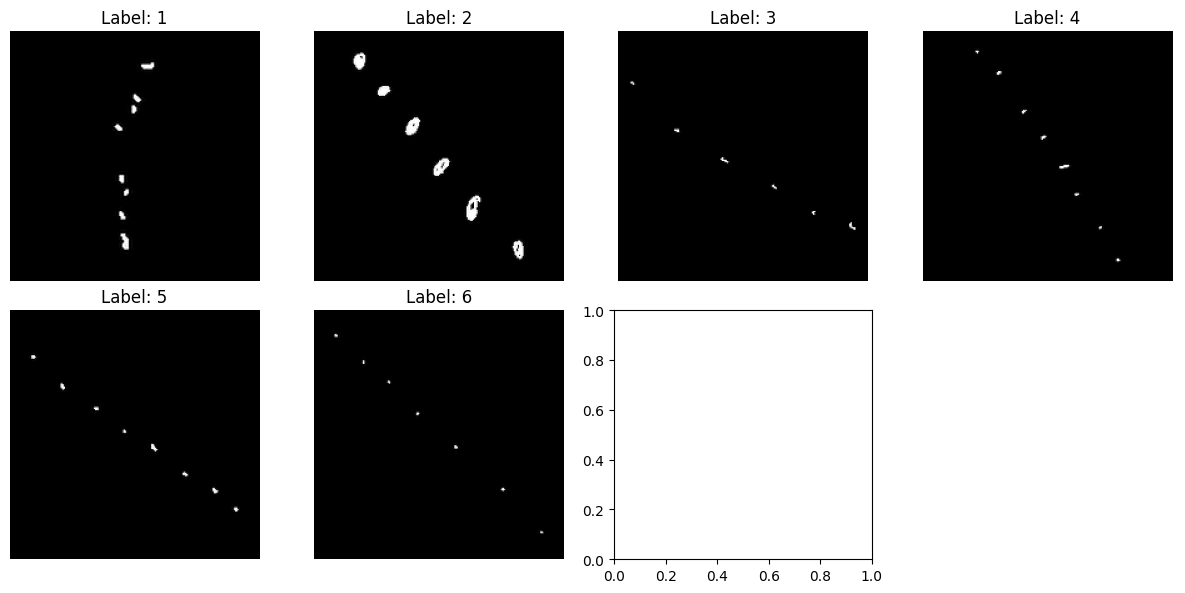


Target count for each class: 215

Split sizes:
Train: 625 (69.9%)
Val: 134 (15.0%)
Test: 135 (15.1%)

Dataset sizes after augmentation:
Train: 1505
Val: 134
Test: 135

Model architecture:
Shape7CNN(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2,

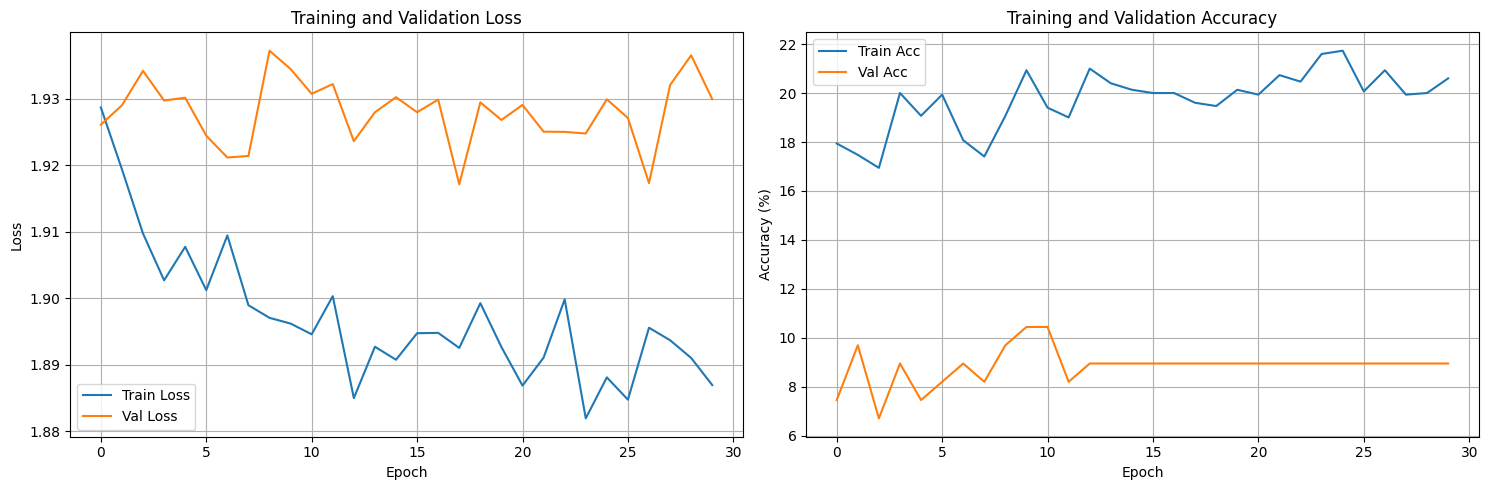


Evaluating on test set...
Test Loss: 1.9278, Test Accuracy: 8.89%

Classification Report:
              precision    recall  f1-score   support

     Label 1       0.09      1.00      0.16        12
     Label 2       0.00      0.00      0.00        24
     Label 3       0.00      0.00      0.00        30
     Label 4       0.00      0.00      0.00        33
     Label 5       0.00      0.00      0.00        20
     Label 6       0.00      0.00      0.00        13
     Label 7       0.00      0.00      0.00         3

    accuracy                           0.09       135
   macro avg       0.01      0.14      0.02       135
weighted avg       0.01      0.09      0.01       135



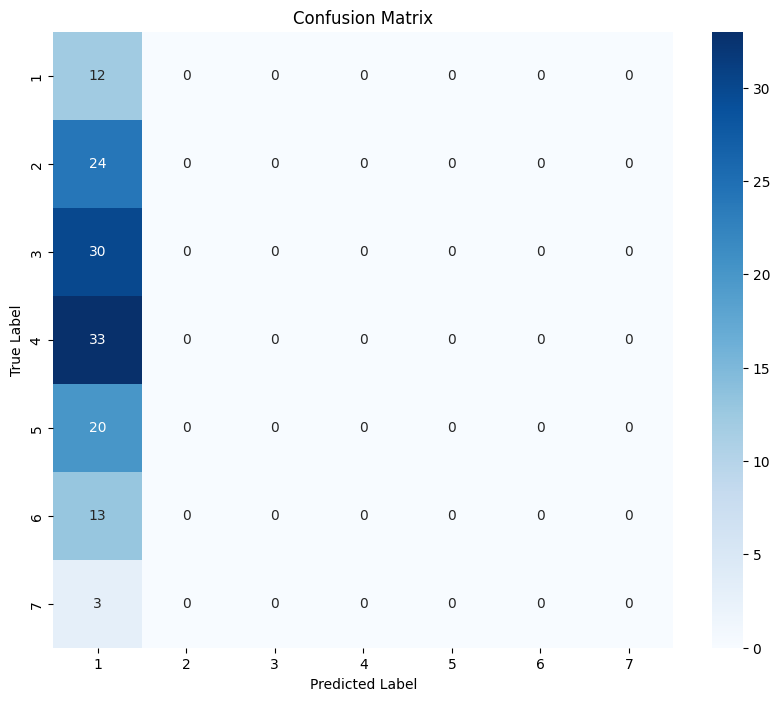


Per-class metrics:
   Label  Precision  Recall  F1-Score  Support
0      1   0.088889     1.0  0.163265       12
1      2   0.000000     0.0  0.000000       24
2      3   0.000000     0.0  0.000000       30
3      4   0.000000     0.0  0.000000       33
4      5   0.000000     0.0  0.000000       20
5      6   0.000000     0.0  0.000000       13
6      7   0.000000     0.0  0.000000        3


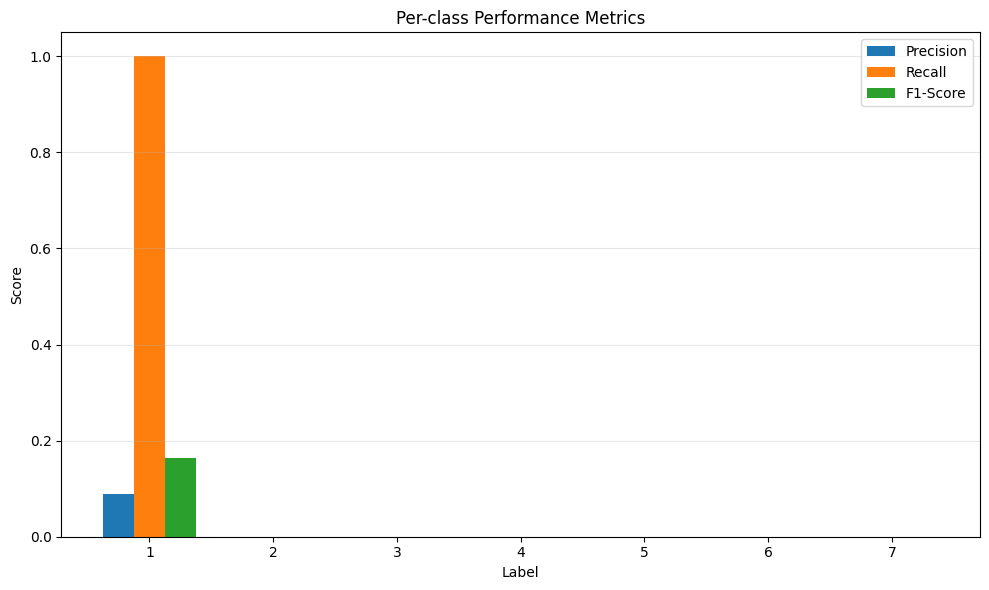


Model saved to /content/shape7_model.pth

Example prediction on a random test image:
True label: 3
Predicted label: 1
Prediction probabilities:
  Label 1: 0.1821
  Label 2: 0.1418
  Label 3: 0.1495
  Label 4: 0.1550
  Label 5: 0.1369
  Label 6: 0.1237
  Label 7: 0.1111


In [1]:
# Shape7 CNN Classification Notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the CSV file
df = pd.read_csv('/content/shape7_labels_all.csv')
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(10, 6))
label_counts = df['label'].value_counts().sort_index()
plt.bar(label_counts.index, label_counts.values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Original Class Distribution')
plt.xticks(range(1, 8))
for i, v in enumerate(label_counts.values):
    plt.text(label_counts.index[i], v + 1, str(v), ha='center')
plt.show()

# Check if all image files exist
image_dir = '/content/shape7'
missing_files = []
for child_id in df['child_id']:
    img_path = os.path.join(image_dir, f"{child_id}.png")
    if not os.path.exists(img_path):
        missing_files.append(child_id)

if missing_files:
    print(f"Warning: {len(missing_files)} image files are missing!")
else:
    print("All image files found!")

# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for label in range(1, 8):
    sample_ids = df[df['label'] == label]['child_id'].values
    if len(sample_ids) > 0:
        sample_id = sample_ids[0]
        img_path = os.path.join(image_dir, f"{sample_id}.png")
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[label-1].imshow(img, cmap='gray')
            axes[label-1].set_title(f'Label: {label}')
            axes[label-1].axis('off')

# Remove empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Custom Dataset with Augmentation
class Shape7Dataset(Dataset):
    def __init__(self, df, image_dir, transform=None, augment=False, oversample_dict=None):
        self.df = df.copy()
        self.image_dir = image_dir
        self.transform = transform
        self.augment = augment

        if oversample_dict and augment:
            # Create augmented samples for balancing
            augmented_rows = []

            for label, target_count in oversample_dict.items():
                current_samples = self.df[self.df['label'] == label]
                current_count = len(current_samples)

                if current_count < target_count:
                    needed = target_count - current_count

                    if label == 1:
                        # For label 1, use rotated versions of labels 5, 6, 7
                        donors = self.df[self.df['label'].isin([5, 6, 7])]
                        if len(donors) > 0:
                            # Sample with replacement if needed
                            sampled = donors.sample(n=min(needed, len(donors) * 3), replace=True)
                            for _, row in sampled.iterrows():
                                if len(augmented_rows) - sum(1 for r in augmented_rows if r['label'] == 1) < needed:
                                    augmented_rows.append({
                                        'child_id': f"{row['child_id']}_rot90_to1",
                                        'label': 1,
                                        'original_id': row['child_id'],
                                        'augmentation': 'rot90_from567'
                                    })
                    else:
                        # For other labels, duplicate with augmentation markers
                        samples_to_add = current_samples.sample(n=needed, replace=True)
                        for idx, (_, row) in enumerate(samples_to_add.iterrows()):
                            augmented_rows.append({
                                'child_id': f"{row['child_id']}_aug{idx}",
                                'label': row['label'],
                                'original_id': row['child_id'],
                                'augmentation': 'standard'
                            })

            if augmented_rows:
                aug_df = pd.DataFrame(augmented_rows)
                self.df = pd.concat([self.df, aug_df], ignore_index=True)
                # Add augmentation info to original samples
                self.df['original_id'] = self.df.apply(
                    lambda x: x.get('original_id', x['child_id']), axis=1
                )
                self.df['augmentation'] = self.df.apply(
                    lambda x: x.get('augmentation', 'none'), axis=1
                )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = row['label'] - 1  # Convert to 0-indexed

        # Get the original image path
        original_id = row.get('original_id', row['child_id'])
        img_path = os.path.join(self.image_dir, f"{original_id}.png")

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            # Create a dummy image if file not found
            image = np.zeros((200, 200), dtype=np.uint8)

        # Apply specific augmentation based on the augmentation type
        aug_type = row.get('augmentation', 'none')

        if aug_type == 'rot90_from567':
            # Rotate 90 degrees for synthetic label 1 samples
            image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
        elif aug_type == 'standard' and self.augment:
            # Apply random augmentations
            if np.random.random() < 0.5:
                # Add Gaussian noise
                noise = np.random.normal(0, 10, image.shape).astype(np.uint8)
                image = cv2.add(image, noise)

            if np.random.random() < 0.5:
                # Small rotation (-5 to 5 degrees)
                angle = np.random.uniform(-5, 5)
                center = (image.shape[1]//2, image.shape[0]//2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))

        # Convert to 3-channel for compatibility with some models
        image = np.stack([image, image, image], axis=-1)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, label

# Calculate target counts for oversampling
max_count = df['label'].value_counts().max()
oversample_dict = {label: max_count for label in range(1, 8)}

print(f"\nTarget count for each class: {max_count}")

# Split the data
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nSplit sizes:")
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Define transforms
train_transform = A.Compose([
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2()
])

# Create datasets
train_dataset = Shape7Dataset(train_df, image_dir, transform=train_transform,
                            augment=True, oversample_dict=oversample_dict)
val_dataset = Shape7Dataset(val_df, image_dir, transform=val_transform)
test_dataset = Shape7Dataset(test_df, image_dir, transform=val_transform)

print(f"\nDataset sizes after augmentation:")
print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Define the CNN model
class Shape7CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(Shape7CNN, self).__init__()

        # First block
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)

        # Second block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)

        # Third block
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.25)

        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.fc1 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # First block
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        # Second block
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)

        # Third block
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.dropout3(x)

        # Global pooling and classifier
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout4(x)
        x = self.fc2(x)

        return x

# Initialize model
model = Shape7CNN(num_classes=7).to(device)
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler - ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                patience=10, verbose=True)

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

# Training loop with early stopping
best_val_acc = 0
best_model_state = None
patience = 20
patience_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("\nStarting training...")
for epoch in range(100):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/100], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc, test_preds, test_labels = validate_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Convert back to 1-indexed labels for reporting
test_preds_1indexed = [p + 1 for p in test_preds]
test_labels_1indexed = [l + 1 for l in test_labels]

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels_1indexed, test_preds_1indexed,
                          target_names=[f'Label {i}' for i in range(1, 8)]))

# Confusion matrix
cm = confusion_matrix(test_labels_1indexed, test_preds_1indexed)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels_1indexed, test_preds_1indexed, average=None
)

metrics_df = pd.DataFrame({
    'Label': range(1, 8),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-class metrics:")
print(metrics_df)

# Plot per-class metrics
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.25

ax.bar(x - width, metrics_df['Precision'], width, label='Precision')
ax.bar(x, metrics_df['Recall'], width, label='Recall')
ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Label')
ax.set_ylabel('Score')
ax.set_title('Per-class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Label'])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
}, '/content/shape7_model.pth')

print("\nModel saved to /content/shape7_model.pth")

# Function to predict on new images
def predict_single_image(model, image_path, device):
    """Predict the label for a single image"""
    model.eval()

    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Could not load image: {image_path}")
        return None

    # Convert to 3-channel
    image = np.stack([image, image, image], axis=-1)

    # Apply transforms
    transform = A.Compose([
        A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ToTensorV2()
    ])

    image = transform(image=image)['image']
    image = image.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)
        probabilities = F.softmax(outputs, dim=1)

    predicted_label = predicted.item() + 1  # Convert back to 1-indexed
    probs = probabilities.cpu().numpy()[0]

    return predicted_label, probs

# Example usage of prediction function
print("\nExample prediction on a random test image:")
test_sample = test_df.iloc[0]
test_image_path = os.path.join(image_dir, f"{test_sample['child_id']}.png")
pred_label, probs = predict_single_image(model, test_image_path, device)

if pred_label is not None:
    print(f"True label: {test_sample['label']}")
    print(f"Predicted label: {pred_label}")
    print(f"Prediction probabilities:")
    for i, prob in enumerate(probs):
        print(f"  Label {i+1}: {prob:.4f}")

Using device: cuda
Total samples: 894
Columns: ['child_id', 'label']

Label distribution:
label
1     79
2    156
3    195
4    215
5    138
6     89
7     22
Name: count, dtype: int64

After removing missing images: 893 samples


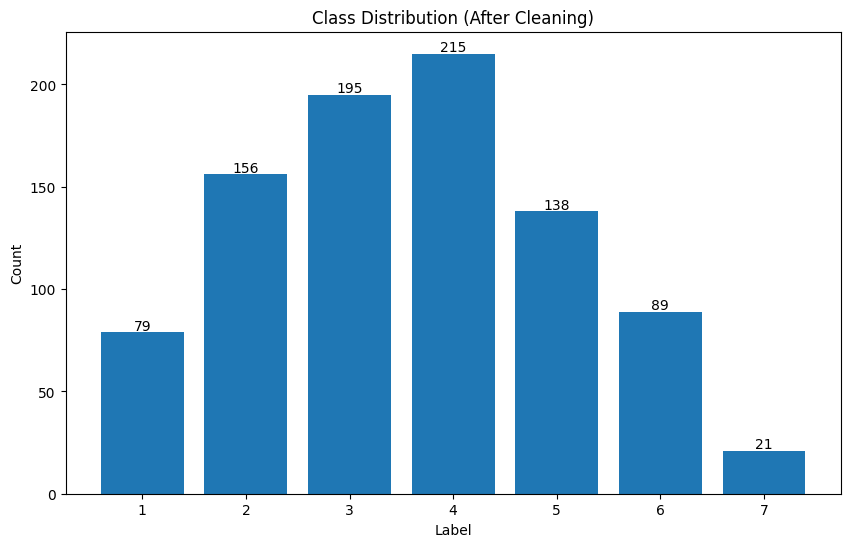

Label 1 - Min: 0, Max: 255, Mean: 1.45
Label 2 - Min: 0, Max: 255, Mean: 3.78
Label 3 - Min: 0, Max: 255, Mean: 0.33
Label 4 - Min: 0, Max: 255, Mean: 0.41
Label 5 - Min: 0, Max: 255, Mean: 0.55
Label 6 - Min: 0, Max: 255, Mean: 0.22
Label 7 - Min: 0, Max: 255, Mean: 0.34


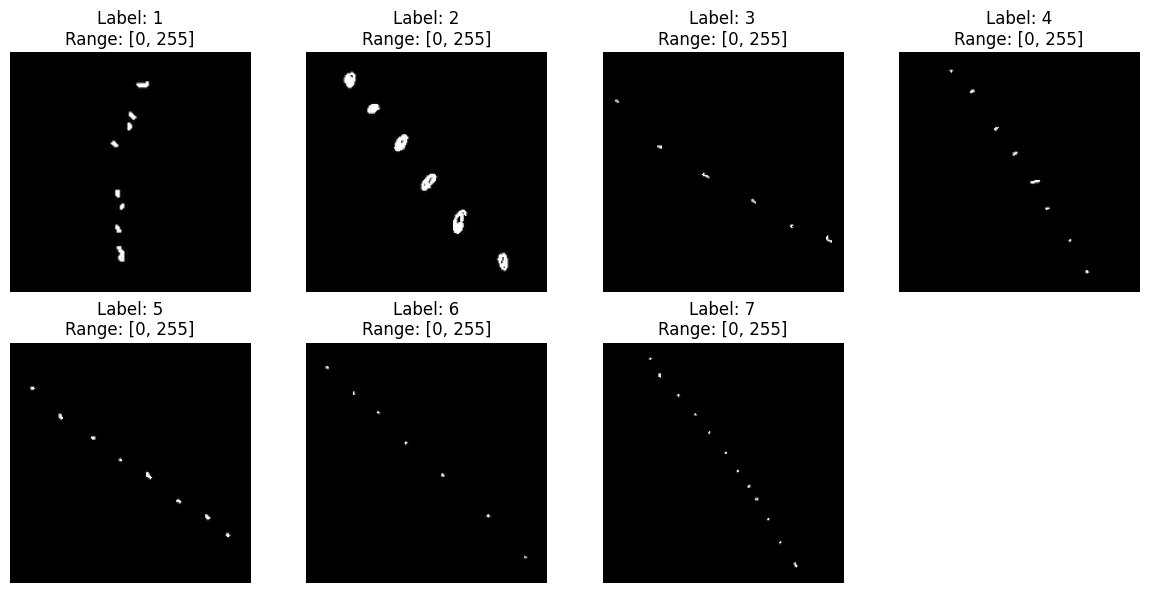


Split sizes:
Train: 625 (70.0%)
Val: 134 (15.0%)
Test: 134 (15.0%)

Model architecture:
SimpleShape7CNN(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=40000, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128,

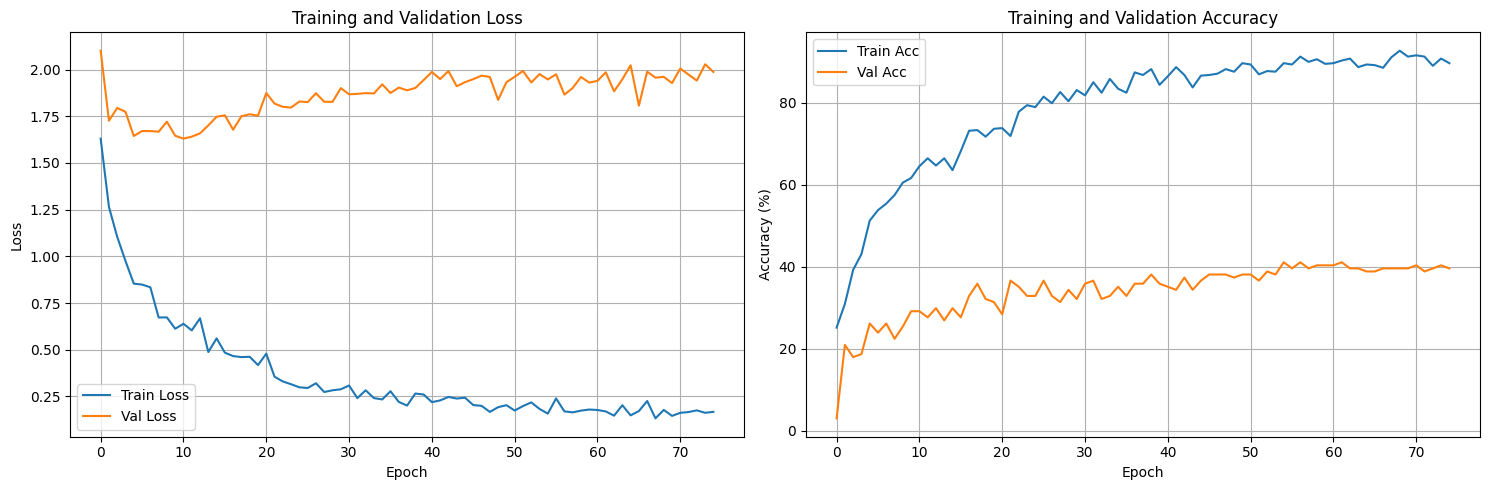


Evaluating on test set...
Test Loss: 2.5373, Test Accuracy: 28.36%

Classification Report:
              precision    recall  f1-score   support

     Label 1       0.86      0.50      0.63        12
     Label 2       0.39      0.38      0.38        24
     Label 3       0.31      0.34      0.33        29
     Label 4       0.23      0.19      0.21        32
     Label 5       0.19      0.24      0.21        21
     Label 6       0.17      0.15      0.16        13
     Label 7       0.00      0.00      0.00         3

    accuracy                           0.28       134
   macro avg       0.31      0.26      0.27       134
weighted avg       0.31      0.28      0.29       134



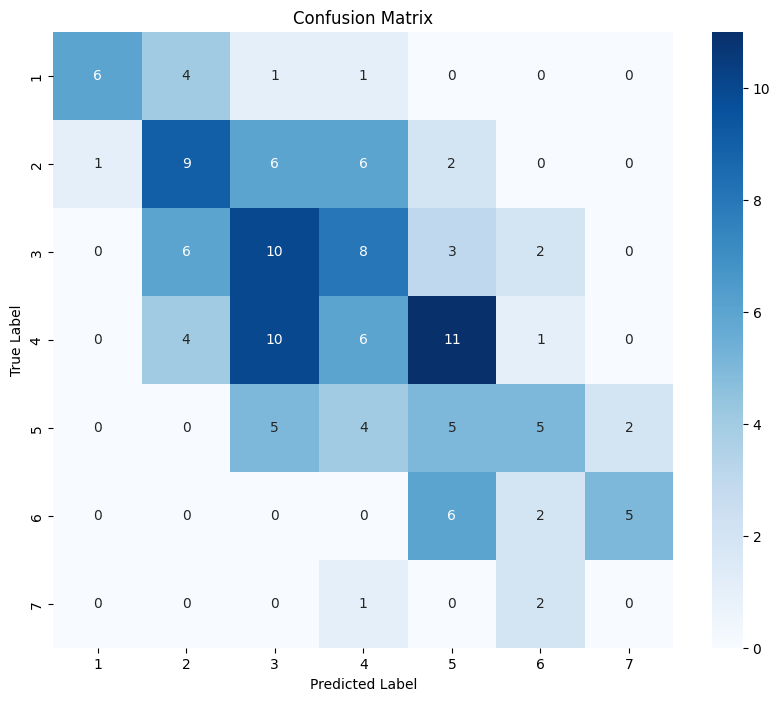


Per-class metrics:
   Label  Precision    Recall  F1-Score  Support
0      1   0.857143  0.500000  0.631579       12
1      2   0.391304  0.375000  0.382979       24
2      3   0.312500  0.344828  0.327869       29
3      4   0.230769  0.187500  0.206897       32
4      5   0.185185  0.238095  0.208333       21
5      6   0.166667  0.153846  0.160000       13
6      7   0.000000  0.000000  0.000000        3


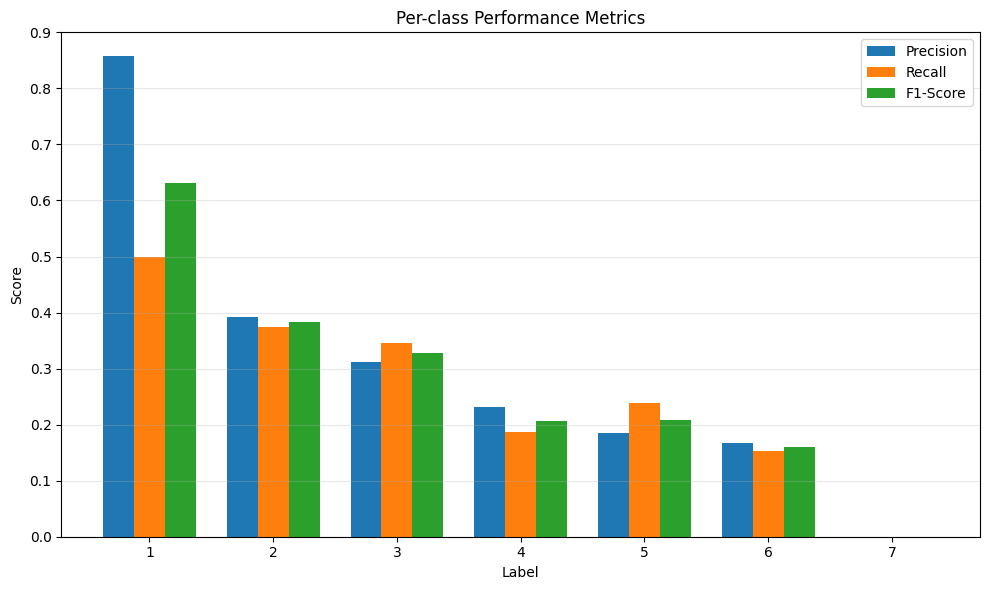


Error Analysis:

True Label 1:
  Misclassified as 2: 4 times
  Misclassified as 3: 1 times
  Misclassified as 4: 1 times

True Label 2:
  Misclassified as 1: 1 times
  Misclassified as 3: 6 times
  Misclassified as 4: 6 times
  Misclassified as 5: 2 times

True Label 3:
  Misclassified as 2: 6 times
  Misclassified as 4: 8 times
  Misclassified as 5: 3 times
  Misclassified as 6: 2 times

True Label 4:
  Misclassified as 2: 4 times
  Misclassified as 3: 10 times
  Misclassified as 5: 11 times
  Misclassified as 6: 1 times

True Label 5:
  Misclassified as 3: 5 times
  Misclassified as 4: 4 times
  Misclassified as 6: 5 times
  Misclassified as 7: 2 times

True Label 6:
  Misclassified as 5: 6 times
  Misclassified as 7: 5 times

True Label 7:
  Misclassified as 4: 1 times
  Misclassified as 6: 2 times

Model saved to /content/shape7_model_revised.pth

Visualizing random test predictions:


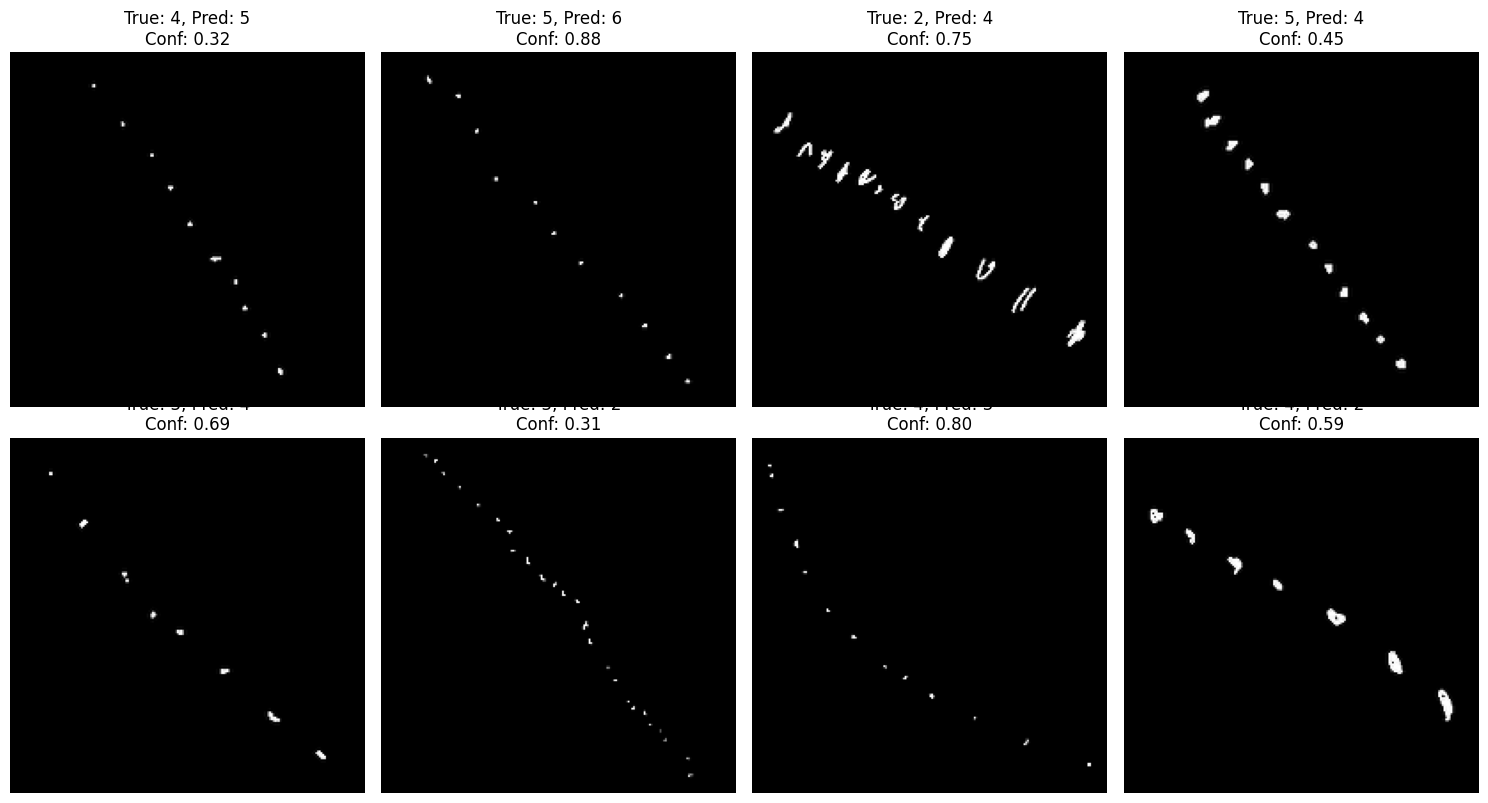

In [2]:
# Shape7 CNN Classification Notebook - Revised

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the CSV file
df = pd.read_csv('/content/shape7_labels_all.csv')
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())

# Remove entries with missing images
image_dir = '/content/shape7'
valid_indices = []
for idx, row in df.iterrows():
    img_path = os.path.join(image_dir, f"{row['child_id']}.png")
    if os.path.exists(img_path):
        valid_indices.append(idx)

df = df.loc[valid_indices].reset_index(drop=True)
print(f"\nAfter removing missing images: {len(df)} samples")

# Visualize class distribution
plt.figure(figsize=(10, 6))
label_counts = df['label'].value_counts().sort_index()
plt.bar(label_counts.index, label_counts.values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Class Distribution (After Cleaning)')
plt.xticks(range(1, 8))
for i, v in enumerate(label_counts.values):
    plt.text(label_counts.index[i], v + 1, str(v), ha='center')
plt.show()

# Display sample images and check pixel values
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for label in range(1, 8):
    sample_ids = df[df['label'] == label]['child_id'].values
    if len(sample_ids) > 0:
        sample_id = sample_ids[0]
        img_path = os.path.join(image_dir, f"{sample_id}.png")
        if os.path.exists(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            axes[label-1].imshow(img, cmap='gray')
            axes[label-1].set_title(f'Label: {label}\nRange: [{img.min()}, {img.max()}]')
            axes[label-1].axis('off')

            # Print pixel statistics
            print(f"Label {label} - Min: {img.min()}, Max: {img.max()}, Mean: {img.mean():.2f}")

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Custom Dataset with Better Augmentation
class Shape7Dataset(Dataset):
    def __init__(self, df, image_dir, transform=None, augment=False):
        self.df = df.copy()
        self.image_dir = image_dir
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = row['label'] - 1  # Convert to 0-indexed

        img_path = os.path.join(self.image_dir, f"{row['child_id']}.png")

        # Load image
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            image = np.zeros((200, 200), dtype=np.uint8)

        # Apply augmentations during training
        if self.augment and np.random.random() < 0.5:
            # Add slight Gaussian noise
            noise = np.random.normal(0, 5, image.shape)
            image = np.clip(image + noise, 0, 255).astype(np.uint8)

            # Small rotation
            if np.random.random() < 0.5:
                angle = np.random.uniform(-5, 5)
                center = (100, 100)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                image = cv2.warpAffine(image, M, (200, 200), borderValue=0)

        # Normalize to [0, 1]
        image = image.astype(np.float32) / 255.0

        # Add channel dimension
        image = np.expand_dims(image, 0)

        # Convert to tensor
        image = torch.FloatTensor(image)

        return image, label

# Split the data
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nSplit sizes:")
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Create datasets
train_dataset = Shape7Dataset(train_df, image_dir, augment=True)
val_dataset = Shape7Dataset(val_df, image_dir, augment=False)
test_dataset = Shape7Dataset(test_df, image_dir, augment=False)

# Calculate class weights for weighted sampling
train_labels = train_df['label'].values - 1  # 0-indexed
class_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_counts + 1e-5)
sample_weights = [class_weights[label] for label in train_labels]

# Create weighted sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Define a simpler CNN model
class SimpleShape7CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleShape7CNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Calculate the size after convolutions
        # 200 -> 100 -> 50 -> 25
        self.fc1 = nn.Linear(64 * 25 * 25, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Initialize model
model = SimpleShape7CNN(num_classes=7).to(device)
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# Calculate class weights for loss function
class_weights = torch.FloatTensor([1.0 / count for count in class_counts]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with lower learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                patience=10, verbose=True, min_lr=1e-6)

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

# Training loop
best_val_acc = 0
best_model_state = None
patience = 20
patience_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("\nStarting training...")
for epoch in range(100):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/100], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # Print prediction distribution to debug
        if (epoch + 1) % 20 == 0:
            pred_counts = np.bincount(val_preds, minlength=7)
            print(f"  Validation predictions distribution: {pred_counts}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc, test_preds, test_labels = validate_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Convert back to 1-indexed labels for reporting
test_preds_1indexed = [p + 1 for p in test_preds]
test_labels_1indexed = [l + 1 for l in test_labels]

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels_1indexed, test_preds_1indexed,
                          target_names=[f'Label {i}' for i in range(1, 8)]))

# Confusion matrix
cm = confusion_matrix(test_labels_1indexed, test_preds_1indexed)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels_1indexed, test_preds_1indexed, average=None, labels=list(range(1, 8))
)

metrics_df = pd.DataFrame({
    'Label': range(1, 8),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-class metrics:")
print(metrics_df)

# Plot per-class metrics
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.25

ax.bar(x - width, metrics_df['Precision'], width, label='Precision')
ax.bar(x, metrics_df['Recall'], width, label='Recall')
ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Label')
ax.set_ylabel('Score')
ax.set_title('Per-class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Label'])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze errors
print("\nError Analysis:")
for true_label in range(1, 8):
    mask = np.array(test_labels_1indexed) == true_label
    if np.sum(mask) > 0:
        preds_for_label = np.array(test_preds_1indexed)[mask]
        unique, counts = np.unique(preds_for_label, return_counts=True)
        print(f"\nTrue Label {true_label}:")
        for pred, count in zip(unique, counts):
            if pred != true_label:
                print(f"  Misclassified as {pred}: {count} times")

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
}, '/content/shape7_model_revised.pth')

print("\nModel saved to /content/shape7_model_revised.pth")

# Visualize some predictions
def visualize_predictions(model, dataset, device, num_samples=8):
    """Visualize predictions on random samples"""
    model.eval()

    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]

        # Get prediction
        with torch.no_grad():
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            _, pred = torch.max(output, 1)
            probs = F.softmax(output, dim=1).cpu().numpy()[0]

        # Display image
        img_display = image.squeeze().numpy()
        axes[i].imshow(img_display, cmap='gray')
        axes[i].set_title(f'True: {true_label+1}, Pred: {pred.item()+1}\nConf: {probs[pred.item()]:.2f}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing random test predictions:")
visualize_predictions(model, test_dataset, device)

EVALUATION WITH ±1 TOLERANCE

Validation Set:
  Standard Accuracy: 39.55%
  Tolerance (±1) Accuracy: 70.90%
  Improvement: +31.34%

Test Set:
  Standard Accuracy: 28.36%
  Tolerance (±1) Accuracy: 79.10%
  Improvement: +50.75%


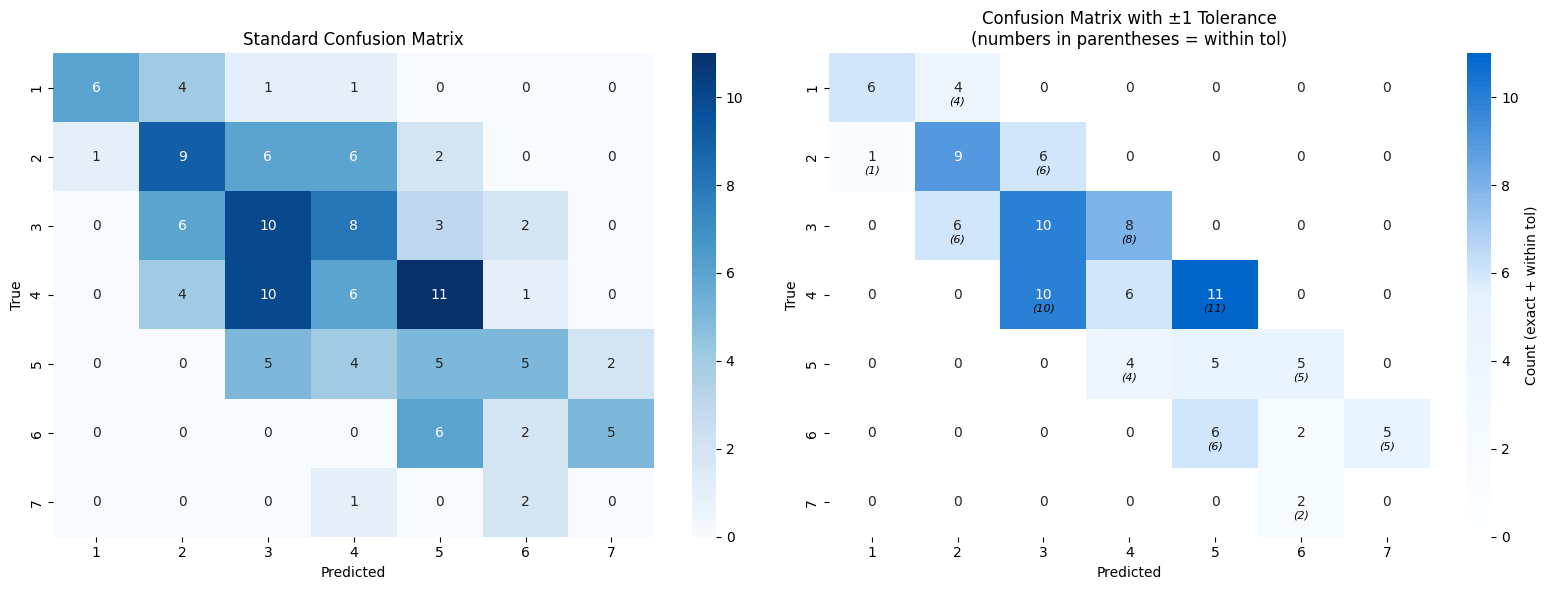


PER-CLASS ANALYSIS WITH TOLERANCE
 Label  Support  Exact Matches  Tolerance Matches  Standard Acc  Tolerance Acc
     1       12              6                  4     50.000000      83.333333
     2       24              9                  7     37.500000      66.666667
     3       29             10                 14     34.482759      82.758621
     4       32              6                 21     18.750000      84.375000
     5       21              5                  9     23.809524      66.666667
     6       13              2                 11     15.384615     100.000000
     7        3              0                  2      0.000000      66.666667


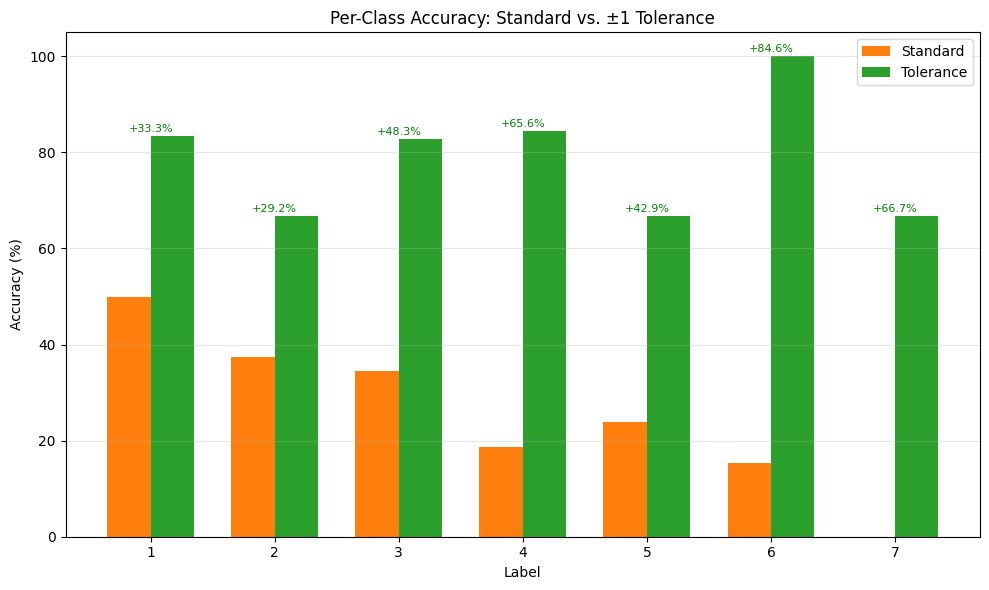


ERROR DISTRIBUTION ANALYSIS


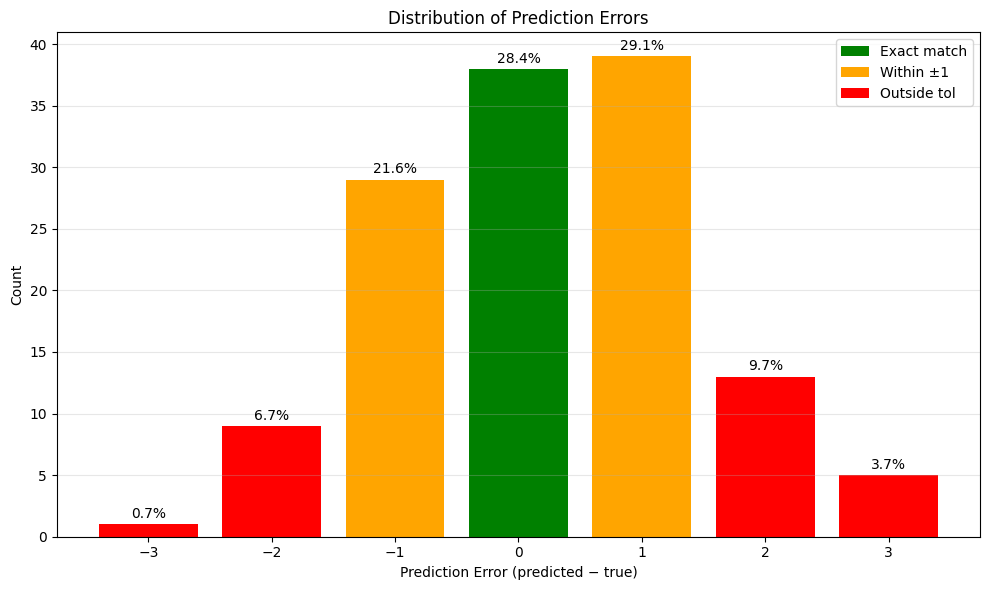


Error Statistics:
  Mean Absolute Error: 0.97
  Std. Dev. of Errors: 1.23
  Predictions within ±1: 106 / 134 (79.1%)
  Predictions within ±2: 128 / 134 (95.5%)

CUSTOM TOLERANCE LOSS FUNCTION
Use it during training with:
  criterion = ToleranceLoss(tolerance=1, tolerance_weight=0.3)


In [5]:
# ============================================================
# Tolerance-Based Evaluation (±1 Label Difference)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def calculate_tolerance_accuracy(predictions, labels, tolerance=1):
    """Return % accuracy where |pred-label| ≤ tolerance is counted as correct."""
    correct = sum(abs(p - l) <= tolerance for p, l in zip(predictions, labels))
    return 100.0 * correct / len(predictions)

def evaluate_with_tolerance(model, loader, device, tolerance=1):
    """Run model on loader and measure standard & tolerance accuracy."""
    model.eval()
    preds, labs = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            labs.extend(lbls.cpu().numpy())

    # Convert to 1-indexed labels
    preds_1, labs_1 = [p + 1 for p in preds], [l + 1 for l in labs]

    std_acc = 100.0 * sum(p == l for p, l in zip(preds_1, labs_1)) / len(preds_1)
    tol_acc = calculate_tolerance_accuracy(preds_1, labs_1, tolerance)
    return preds_1, labs_1, std_acc, tol_acc

def create_tolerance_confusion_matrix(preds, labs, num_classes=7):
    """3-channel matrix: exact, within-tolerance, wrong."""
    cm = np.zeros((num_classes, num_classes, 3), dtype=int)
    for p, t in zip(preds, labs):
        p_i, t_i = p - 1, t - 1
        if p == t:
            cm[t_i, p_i, 0] += 1            # exact
        elif abs(p - t) == 1:
            cm[t_i, p_i, 1] += 1            # within ±1
        else:
            cm[t_i, p_i, 2] += 1            # wrong
    return cm

# ------------------------------------------------------------------
# Evaluate on validation & test sets
# ------------------------------------------------------------------
print("=" * 60)
print("EVALUATION WITH ±1 TOLERANCE")
print("=" * 60)

val_preds, val_labs, val_std, val_tol = evaluate_with_tolerance(model, val_loader, device)
print(f"\nValidation Set:\n  Standard Accuracy: {val_std:.2f}%"
      f"\n  Tolerance (±1) Accuracy: {val_tol:.2f}%"
      f"\n  Improvement: +{val_tol - val_std:.2f}%")

test_preds, test_labs, test_std, test_tol = evaluate_with_tolerance(model, test_loader, device)
print(f"\nTest Set:\n  Standard Accuracy: {test_std:.2f}%"
      f"\n  Tolerance (±1) Accuracy: {test_tol:.2f}%"
      f"\n  Improvement: +{test_tol - test_std:.2f}%")

# ------------------------------------------------------------------
# Confusion-matrix visualisations
# ------------------------------------------------------------------
tol_cm = create_tolerance_confusion_matrix(test_preds, test_labs)
std_cm = confusion_matrix(test_labs, test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Standard CM
sns.heatmap(std_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 8), yticklabels=range(1, 8), ax=ax1)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True'); ax1.set_title('Standard Confusion Matrix')

# Tolerance CM
tol_combined = (tol_cm[:, :, 0] + tol_cm[:, :, 1]).astype(int)  # make sure it's int!
mask = tol_cm[:, :, 1] > 0

cmap = LinearSegmentedColormap.from_list('tolerance', ['white', '#e6f3ff', '#0066cc'], N=100)
sns.heatmap(tol_combined, annot=True, fmt='d', cmap=cmap,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            ax=ax2, cbar_kws={'label': 'Count (exact + within tol)'})

for i in range(7):
    for j in range(7):
        if mask[i, j]:
            ax2.text(j + 0.5, i + 0.7,
                     f'({tol_cm[i, j, 1]})', ha='center', va='center',
                     fontsize=8, style='italic')

ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix with ±1 Tolerance\n(numbers in parentheses = within tol)')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Per-class accuracy table & bar chart
# ------------------------------------------------------------------
analysis_rows = []
for lbl in range(1, 8):
    msk = np.array(test_labs) == lbl
    preds_lbl = np.array(test_preds)[msk]
    exact = (preds_lbl == lbl).sum()
    within = (np.abs(preds_lbl - lbl) == 1).sum()
    support = msk.sum()
    analysis_rows.append({
        'Label': lbl,
        'Support': support,
        'Exact Matches': exact,
        'Tolerance Matches': within,
        'Standard Acc': 100.0 * exact / support,
        'Tolerance Acc': 100.0 * (exact + within) / support
    })

analysis_df = pd.DataFrame(analysis_rows)
print("\n" + "="*60 + "\nPER-CLASS ANALYSIS WITH TOLERANCE\n" + "="*60)
print(analysis_df.to_string(index=False))

# Bar chart
x = np.arange(len(analysis_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, analysis_df['Standard Acc'], width, label='Standard', color='#ff7f0e')
ax.bar(x + width/2, analysis_df['Tolerance Acc'], width, label='Tolerance', color='#2ca02c')
for i, (s, t) in enumerate(zip(analysis_df['Standard Acc'], analysis_df['Tolerance Acc'])):
    diff = t - s
    if diff > 0:
        ax.annotate(f'+{diff:.1f}%',
                    xy=(i, t), xytext=(0, 3),
                    textcoords='offset points', ha='center', fontsize=8, color='green')
ax.set_xlabel('Label'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: Standard vs. ±1 Tolerance')
ax.set_xticks(x); ax.set_xticklabels(analysis_df['Label'])
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# Error-distribution histogram
# ------------------------------------------------------------------
print("\n" + "="*60 + "\nERROR DISTRIBUTION ANALYSIS\n" + "="*60)
errors = np.array(test_preds) - np.array(test_labs)
uniq_err, counts = np.unique(errors, return_counts=True)

plt.figure(figsize=(10, 6))
bar_colors = ['green' if e == 0 else 'orange' if abs(e) == 1 else 'red' for e in uniq_err]
plt.bar(uniq_err, counts, color=bar_colors)
plt.xlabel('Prediction Error (predicted − true)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.grid(axis='y', alpha=0.3)
for e, c in zip(uniq_err, counts):
    plt.text(e, c + 0.5, f'{(c/len(errors))*100:.1f}%', ha='center')
plt.legend(handles=[
    Patch(facecolor='green',  label='Exact match'),
    Patch(facecolor='orange', label='Within ±1'),
    Patch(facecolor='red',    label='Outside tol')],
           loc='upper right')
plt.tight_layout(); plt.show()

print("\nError Statistics:")
print(f"  Mean Absolute Error: {np.abs(errors).mean():.2f}")
print(f"  Std. Dev. of Errors: {errors.std():.2f}")
print(f"  Predictions within ±1: {(np.abs(errors) <= 1).sum()} / {len(errors)} "
      f"({(np.abs(errors) <= 1).mean()*100:.1f}%)")
print(f"  Predictions within ±2: {(np.abs(errors) <= 2).sum()} / {len(errors)} "
      f"({(np.abs(errors) <= 2).mean()*100:.1f}%)")

# ------------------------------------------------------------------
# Custom tolerance-aware loss (optional for training)
# ------------------------------------------------------------------
class ToleranceLoss(nn.Module):
    """Cross-entropy with reduced penalty for |pred-label| ≤ tolerance."""
    def __init__(self, tolerance=1, tolerance_weight=0.3):
        super().__init__()
        self.tolerance = tolerance
        self.tol_weight = tolerance_weight
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, outputs, targets):
        base_losses = self.ce(outputs, targets)
        preds = torch.argmax(outputs, 1)
        err = torch.abs(preds - targets)
        weights = torch.where(err == 0,
                              torch.ones_like(err, dtype=torch.float),
                              torch.where(err <= self.tolerance,
                                          torch.full_like(err, self.tol_weight, dtype=torch.float),
                                          torch.ones_like(err, dtype=torch.float)))
        return (base_losses * weights).mean()

print("\n" + "="*60 + "\nCUSTOM TOLERANCE LOSS FUNCTION\n" + "="*60)
print("Use it during training with:")
print("  criterion = ToleranceLoss(tolerance=1, tolerance_weight=0.3)")


Running on cuda
Loaded 894 records
After removing missing images: 893
label
1     79
2    156
3    195
4    215
5    138
6     89
7     21
Name: count, dtype: int64
Train/Val/Test: 625/134/134


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s]

11.170753 M parameters


Epoch 01: train MAE 1.850 | val MAE 1.643 | std 19.4% | tol±1 51.5%
Epoch 02: train MAE 0.738 | val MAE 0.913 | std 29.9% | tol±1 81.3%
Epoch 03: train MAE 0.680 | val MAE 1.016 | std 29.9% | tol±1 74.6%
Epoch 04: train MAE 0.568 | val MAE 0.903 | std 23.1% | tol±1 85.8%
Epoch 05: train MAE 0.549 | val MAE 0.839 | std 41.0% | tol±1 82.8%
Epoch 06: train MAE 0.505 | val MAE 0.761 | std 43.3% | tol±1 87.3%
Epoch 07: train MAE 0.507 | val MAE 0.791 | std 42.5% | tol±1 85.8%
Epoch 08: train MAE 0.515 | val MAE 0.886 | std 35.8% | tol±1 82.8%
Epoch 09: train MAE 0.465 | val MAE 0.892 | std 41.0% | tol±1 79.9%
Epoch 10: train MAE 0.459 | val MAE 0.751 | std 48.5% | tol±1 84.3%
Epoch 11: train MAE 0.497 | val MAE 0.782 | std 41.0% | tol±1 84.3%
Epoch 12: train MAE 0.482 | val MAE 0.759 | std 41.8% | tol±1 86.6%
Epoch 13: train MAE 0.436 | val MAE 0.807 | std 41.0% | tol±1 85.1%
Epoch 14: train MAE 0.401 | val MAE 0.904 | std 32.8% | tol±1 80.6%
Epoch 15: train MAE 0.410 | val MAE 0.719 | std 

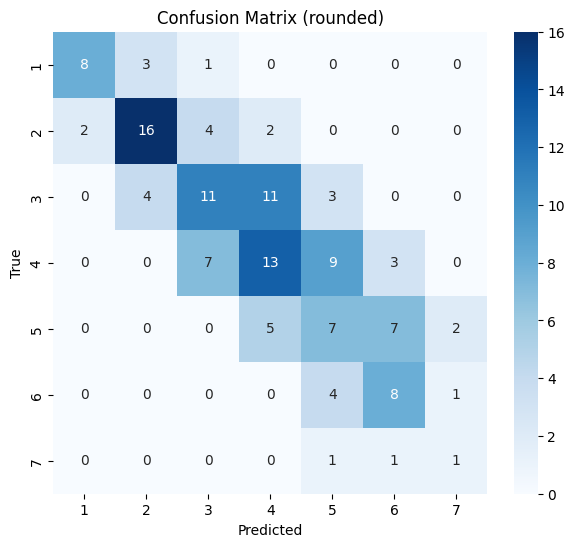

Model weights saved to /content/shape7_resnet_reg.pth


In [7]:
# Shape‑7 Drawing‑Score Model 🚀
# Full notebook implementing: auto‑crop preprocessing, stronger augmentation,
# lightweight transfer‑learning backbone (ResNet‑18), scalar regression
# with Huber loss, tolerance‑aware metrics, and Grad‑CAM visualisation.
# Cell boundaries are marked with `# %%` so you can paste the file straight
# into VS Code / Jupyter and run cell‑by‑cell.

# ---------------------------------------------------------------------------
# %% 1. Imports & basic setup
# ---------------------------------------------------------------------------
import os, random, warnings, math, time
import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import models
from torchvision.transforms import functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

# ---------------------------------------------------------------------------
# %% 2. Paths & hyper‑parameters (edit as needed)
# ---------------------------------------------------------------------------
CSV_PATH   = "/content/shape7_labels_all.csv"   # <- change if needed
IMG_DIR    = "/content/shape7"                   # <- PNGs, one per child_id
IMG_SIZE   = 128                                  # resized square size
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 3e-4
PATIENCE   = 10                                   # early stopping
TOLERANCE  = 1                                    # for ±1 accuracy
MODEL_OUT  = "/content/shape7_resnet_reg.pth"

# ---------------------------------------------------------------------------
# %% 3. Utility: Smart auto‑crop to bounding‑box of strokes
# ---------------------------------------------------------------------------

def smart_center_crop(img_np: np.ndarray, thr: int = 20):
    """Crop numpy (H,W) image to square bounding‑box around non‑black pixels."""
    ys, xs = np.where(img_np > thr)
    if len(xs) == 0:
        return img_np                        # blank – return as is
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    # make square
    side = max(x1 - x0, y1 - y0) + 2  # +2 px margin
    cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
    half = side // 2
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half
    # pad if crop touches border
    pad_x0, pad_y0 = max(-x0, 0), max(-y0, 0)
    pad_x1 = max(x1 - img_np.shape[1] + 1, 0)
    pad_y1 = max(y1 - img_np.shape[0] + 1, 0)
    if any([pad_x0, pad_x1, pad_y0, pad_y1]):
        img_np = np.pad(img_np, ((pad_y0, pad_y1), (pad_x0, pad_x1)), constant_values=0)
        y0 += pad_y0; y1 += pad_y0; x0 += pad_x0; x1 += pad_x0
    return img_np[y0:y1+1, x0:x1+1]

# helper Albumentations transform wrapper
class SmartCropTransform:
    def __init__(self, thr=20):
        self.thr = thr
    def __call__(self, img, **kwargs):
        return smart_center_crop(img, thr=self.thr)

# ---------------------------------------------------------------------------
# %% 4. Dataset & transforms
# ---------------------------------------------------------------------------

a_train = A.Compose([
    A.Lambda(image=SmartCropTransform(thr=20)),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10,
                       border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=16, max_width=16, fill_value=0, p=0.3),
    ToTensorV2()
])

a_val = A.Compose([
    A.Lambda(image=SmartCropTransform(thr=20)),
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2()
])

class Shape7Dataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, transform, mode="train"):
        self.df = df.reset_index(drop=True)
        self.dir = img_dir
        self.transform = transform
        self.mode = mode
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.dir, f"{row['child_id']}.png")
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((200,200), dtype=np.uint8)
        augmented = self.transform(image=img)
        tensor = augmented["image"].float() / 255.0  # scale 0‑1
        # channel dim already first because ToTensorV2 gives C,H,W for gray
        label = torch.tensor(row['label'], dtype=torch.float32)  # scalar
        return tensor, label

# ---------------------------------------------------------------------------
# %% 5. Load CSV, filter missing images, split
# ---------------------------------------------------------------------------

df = pd.read_csv(CSV_PATH)
print("Loaded", len(df), "records")
# keep only existing images
mask_exists = df['child_id'].apply(lambda cid: os.path.exists(os.path.join(IMG_DIR, f"{cid}.png")))
df = df[mask_exists].reset_index(drop=True)
print("After removing missing images:", len(df))
print(df['label'].value_counts().sort_index())

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
print(f"Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}")

# Weighted sampler for imbalance
train_counts = train_df['label'].value_counts().sort_index().values  # labels 1‑7
weights = 1.0 / (train_counts + 1e-6)
sample_weights = train_df['label'].apply(lambda l: weights[int(l)-1]).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(Shape7Dataset(train_df, IMG_DIR, a_train), batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(Shape7Dataset(val_df,   IMG_DIR, a_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(Shape7Dataset(test_df,  IMG_DIR, a_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ---------------------------------------------------------------------------
# %% 6. Model: ResNet‑18 backbone with scalar regression head
# ---------------------------------------------------------------------------

class ResNet18Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # adapt first conv to 1‑channel
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # keep batch‑norm weights from pretrain (they broadcast fine)
        # replace fc
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)  # scalar output
    def forward(self, x):
        return self.backbone(x).squeeze(1)            # (B,)

model = ResNet18Reg().to(device)
print(sum(p.numel() for p in model.parameters())/1e6, "M parameters")

# Freeze most layers except last block + fc
for name, param in model.backbone.named_parameters():
    param.requires_grad = name.startswith("layer4") or name.startswith("fc")

opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3, min_lr=1e-6, verbose=True)
criterion = nn.SmoothL1Loss(beta=1.0)  # aka Huber

# ---------------------------------------------------------------------------
# %% 7. Helper metrics
# ---------------------------------------------------------------------------

def mae(preds, trues):
    return torch.mean(torch.abs(preds - trues)).item()

def accuracy_std(preds, trues):
    return (torch.round(preds).int() == trues.int()).float().mean().item() * 100

def accuracy_tol(preds, trues, tol=TOLERANCE):
    return (torch.abs(torch.round(preds) - trues) <= tol).float().mean().item() * 100

# ---------------------------------------------------------------------------
# %% 8. Training loop with early stopping
# ---------------------------------------------------------------------------

best_val_mae = np.inf
patience_counter = 0
train_hist = {"epoch": [], "train_mae": [], "val_mae": [], "val_std": [], "val_tol": []}

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        opt.step()
        running_loss += loss.item() * x.size(0)
    train_mae = running_loss / len(train_loader.dataset)

    # validation
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds.append(out.cpu()); labels.append(y.cpu())
    preds = torch.cat(preds); labels = torch.cat(labels)
    val_mae   = mae(preds, labels)
    val_std   = accuracy_std(preds, labels)
    val_tol   = accuracy_tol(preds, labels)
    sched.step(val_mae)

    train_hist["epoch"].append(epoch)
    train_hist["train_mae"].append(train_mae)
    train_hist["val_mae"].append(val_mae)
    train_hist["val_std"].append(val_std)
    train_hist["val_tol"].append(val_tol)

    print(f"Epoch {epoch:02d}: train MAE {train_mae:.3f} | val MAE {val_mae:.3f} | std {val_std:.1f}% | tol±{TOLERANCE} {val_tol:.1f}%")

    if val_mae < best_val_mae - 1e-3:
        best_val_mae = val_mae
        torch.save(model.state_dict(), MODEL_OUT)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping ✔️")
            break

# ---------------------------------------------------------------------------
# %% 9. Load best model & evaluate on test set
# ---------------------------------------------------------------------------

model.load_state_dict(torch.load(MODEL_OUT, map_location=device))
model.eval(); preds, labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds.append(out.cpu()); labels.append(y.cpu())
preds = torch.cat(preds); labels = torch.cat(labels)

test_mae = mae(preds, labels)
std_acc  = accuracy_std(preds, labels)
tol_acc = accuracy_tol(preds, labels)
print(f"\nTEST  MAE {test_mae:.3f} | std {std_acc:.1f}% | tol±{TOLERANCE} {tol_acc:.1f}%\n")

# ---------------------------------------------------------------------------
# %% 10. Confusion matrix & error distribution (rounded preds)
# ---------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix
rounded = torch.round(preds).clamp(1,7).int().numpy()
cm = confusion_matrix(labels.int().numpy(), rounded, labels=range(1,8))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1,8), yticklabels=range(1,8))
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (rounded)")
plt.show()

# ---------------------------------------------------------------------------
# %% 11. Grad‑CAM visualisation helper (optional)
# ---------------------------------------------------------------------------

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    def __call__(self, x, index=None):
        self.model.zero_grad()
        out = self.model(x)
        if index is None:
            index = torch.argmax(out, dim=1)
        one_hot = torch.zeros_like(out); one_hot.scatter_(1, index.unsqueeze(1), 1.0)
        out.backward(gradient=one_hot, retain_graph=True)
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

# Example usage after training:
# cam_extractor = GradCAM(model, model.backbone.layer4[-1])
# img_tensor, _ = test_loader.dataset[0]
# heatmap = cam_extractor(img_tensor.unsqueeze(0).to(device))
# plt.imshow(img_tensor.squeeze(), cmap='gray'); plt.imshow(heatmap, alpha=0.4, cmap='jet'); plt.show()

# ---------------------------------------------------------------------------
# %% 12. Done – model saved, metrics printed
# ---------------------------------------------------------------------------
print(f"Model weights saved to {MODEL_OUT}")


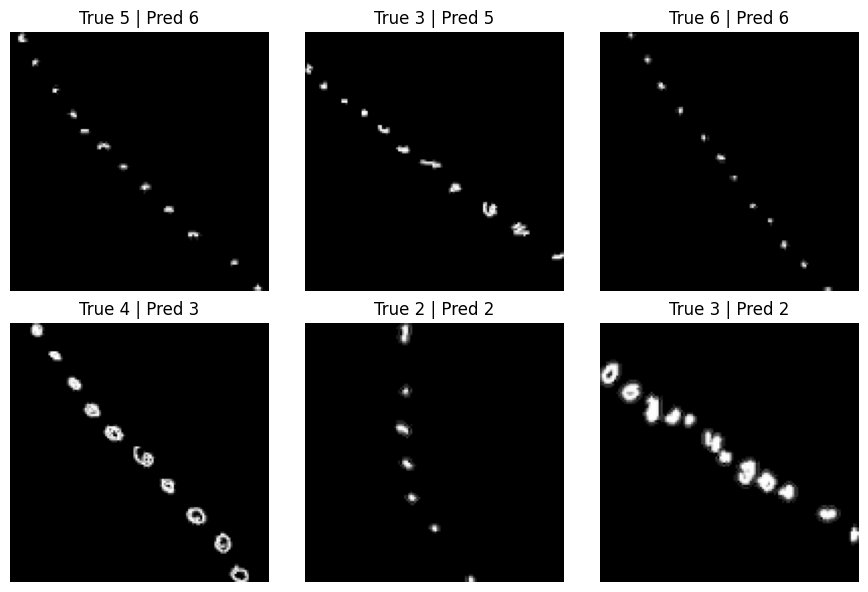

In [16]:
# %% 11-bis — Fine-resolution signed Grad-CAM (layer2, 32×32)
# -----------------------------------------------------------
import matplotlib.cm as cm
import torch.nn.functional as F

class GradCAMRegFine:
    """Grad-CAM for scalar regression with a 32×32 map (layer2)."""
    def __init__(self, model):
        self.model = model
        self.target = model.backbone.layer2[-1].conv2   # finer spatial grid
        self.activ = self.grad = None
        self.target.register_forward_hook(self._save_act)
        self.target.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):  self.activ = o
    def _save_grad(self, m, gi, go): self.grad = go[0]

    def __call__(self, x):
        self.model.zero_grad()
        self.model(x).backward(retain_graph=True)

        # If grad somehow None, return zeros
        if self.grad is None:
            return torch.zeros((IMG_SIZE, IMG_SIZE))

        w   = self.grad.mean(dim=(2, 3), keepdim=True)           # global-avg-pool
        cam = (w * self.activ).sum(dim=1, keepdim=True)          # keep sign
        cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        return cam.squeeze().detach().cpu()                      # signed H×W tensor

cam_extractor = GradCAMRegFine(model)

def show_signed_gradcam(dataset, n=6):
    idxs = np.random.choice(len(dataset), n, replace=False)
    cols = n if n <= 5 else int(np.ceil(n/2)); rows = 1 if n <= 5 else 2
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.atleast_2d(axes).ravel()

    model.eval()
    for ax, idx in zip(axes, idxs):
        img_tensor, true_lbl = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)

        heat = cam_extractor(x)                     # signed tensor H×W
        pos, neg = F.relu( heat).numpy(), F.relu(-heat).numpy()
        if pos.max(): pos /= pos.max()
        if neg.max(): neg /= neg.max()

        # prepare grayscale base (gamma-corrected for visibility)
        gray = img_tensor.squeeze().cpu().numpy()**0.4            # H×W
        base = np.repeat(gray[..., None], 3, axis=2)              # H×W×3
        base += np.dstack([pos, np.zeros_like(pos), neg])         # red=+, blue=–

        base = np.clip(base, 0, 1)

        with torch.no_grad():
            pred = torch.round(model(x)).item()

        ax.imshow(base)
        ax.set_title(f"True {int(true_lbl)} | Pred {int(pred)}")
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

# -- run once --
show_signed_gradcam(test_loader.dataset, n=6)
